In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import LabelEncoder

plt.style.use('default')

## **Problem 1 to 2:**

**Dataset link:** https://rb.gy/gsmddu

**Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **Problem-1:** Make a subplots which have 2 plots.

- For the first chart, draw a scatter plot "*Monitored Cap.(MW)*" vs "*Total Cap. Under Maintenance (MW)*" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.


In [2]:
# code here

df = pd.read_csv("datasets/PowerGeneration - PowerGeneration.csv")
print(df.columns)
df.head(3)

Index(['Dates', 'Power Station', 'Monitored Cap.(MW)',
       'Total Cap. Under Maintenace (MW)', 'Planned Maintanence (MW)',
       'Forced Maintanence(MW)', 'Other Reasons (MW)',
       'Programme or Expected(MU)', 'Actual(MU)', 'Excess(+) / Shortfall (-)',
       'Deviation'],
      dtype='object')


,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.0,0.0,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.0,0.0,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.0,0.0,231.0,0,40,46,5.63,0.0


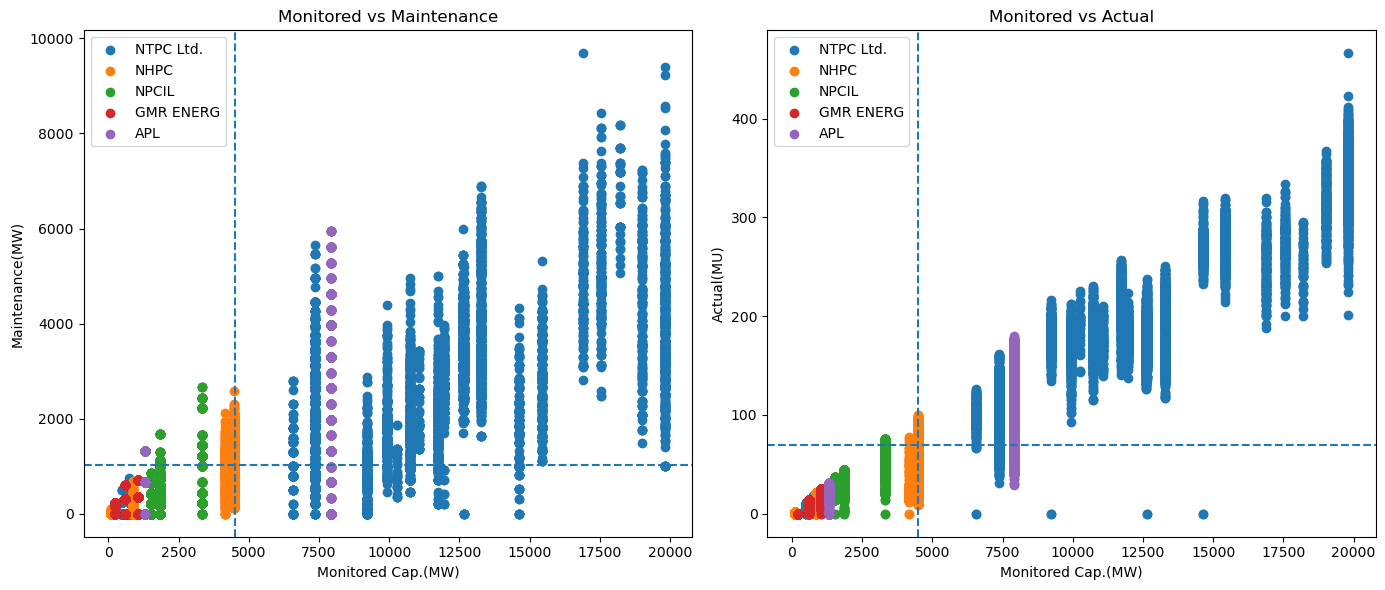

In [3]:
top5 = df["Power Station"].value_counts().head(5).index
d = df[df["Power Station"].isin(top5)]

fig, ax = plt.subplots(1, 2, figsize=(14,6))

for s in top5:
    x = d[d["Power Station"]==s]
    ax[0].scatter(x["Monitored Cap.(MW)"], x["Total Cap. Under Maintenace (MW)"], label=s)
    ax[1].scatter(x["Monitored Cap.(MW)"], x["Actual(MU)"], label=s)

ax[0].axvline(d["Monitored Cap.(MW)"].mean(), ls="--")
ax[0].axhline(d["Total Cap. Under Maintenace (MW)"].mean(), ls="--")

ax[1].axvline(d["Monitored Cap.(MW)"].mean(), ls="--")
ax[1].axhline(d["Actual(MU)"].mean(), ls="--")

ax[0].set(title="Monitored vs Maintenance", xlabel="Monitored Cap.(MW)", ylabel="Maintenance(MW)")
ax[1].set(title="Monitored vs Actual", xlabel="Monitored Cap.(MW)", ylabel="Actual(MU)")

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()

### **Problem-2:** Draw a 3D Scatter plot between "*Monitored Cap.(MW)*", "*Total Cap. Under Maintenace (MW)*" and "*Forced Maintanence(MW)*"

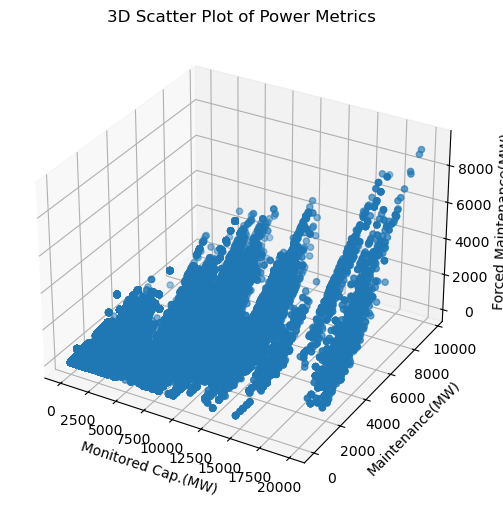

In [4]:
# code here

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["Monitored Cap.(MW)"],
    df["Total Cap. Under Maintenace (MW)"],
    df["Forced Maintanence(MW)"]
)

ax.set_xlabel("Monitored Cap.(MW)")
ax.set_ylabel("Maintenance(MW)")
ax.set_zlabel("Forced Maintenance(MW)")
ax.set_title("3D Scatter Plot of Power Metrics")

plt.show()

### **Problem-3:** Make a 3D *Surface* plot of this below mathematical equation.

$$z = |x| - |y|$$

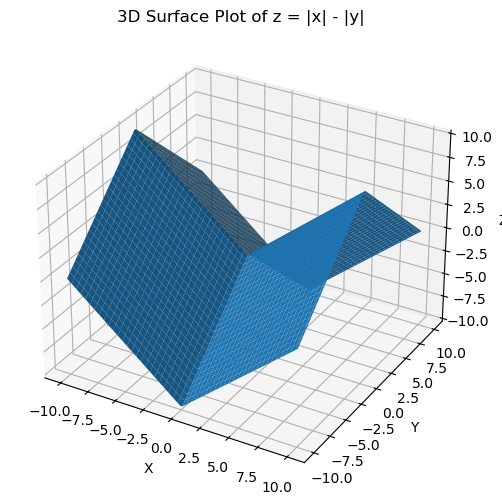

In [5]:
# code here

x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
x, y = np.meshgrid(x, y)

z = np.abs(x) - np.abs(y)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x, y, z)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Surface Plot of z = |x| - |y|")

plt.show()

### **Problem-4:** Draw the 3D *Contour plot* of this below equation:

$$z = |x| - |y|$$

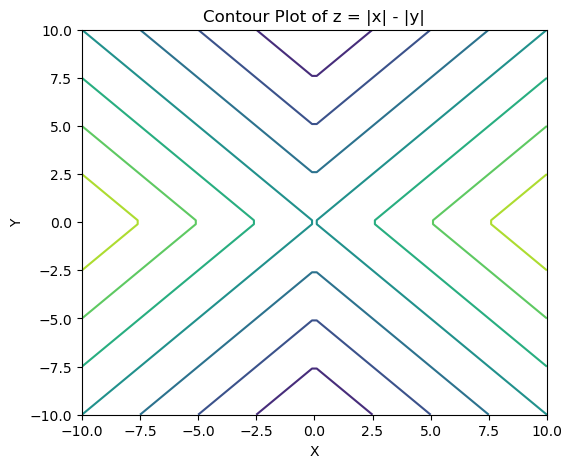

In [6]:
# code here 

plt.figure(figsize=(6,5))
plt.contour(x, y, z)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Contour Plot of z = |x| - |y|")

plt.show()

### **Problem-5:** Draw a second type of Countour plot of the below equation:

$$z = |x| - |y|$$

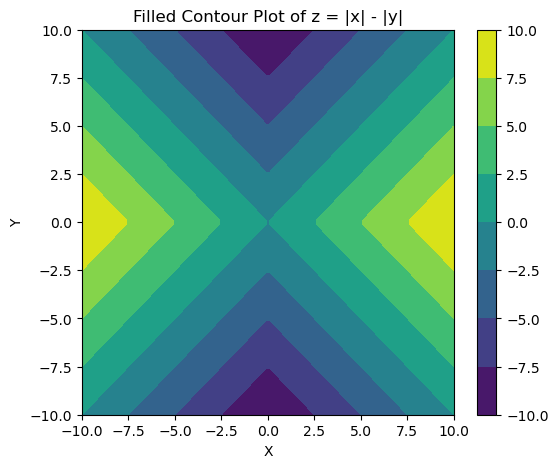

In [7]:
# code here

plt.figure(figsize=(6,5))
plt.contourf(x, y, z)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Filled Contour Plot of z = |x| - |y|")

plt.colorbar()

plt.show()

## `Problem 6-7`

Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link


**Description of Dataset:**

* Date: It gives the date of which stocks details are given.
* Symbol: Name of stock
* Open: It gives the opening price of stock on that date.
* High: It gives the highest price to which the stock ascened on that day.
* Low: It gives the highest price to which the stock plummeted on that day.
* Close: It gives the closing price of stock on that date.
* Volume: It gives the amount of stock traded on that date.
* VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.
* Turnover:

### `Problem-6` Use Pandas plot functions

* Line plot of closing value of top 5 Stocks in Year 2020.
* Take top 5 stocks based on total turnover in Year 2020

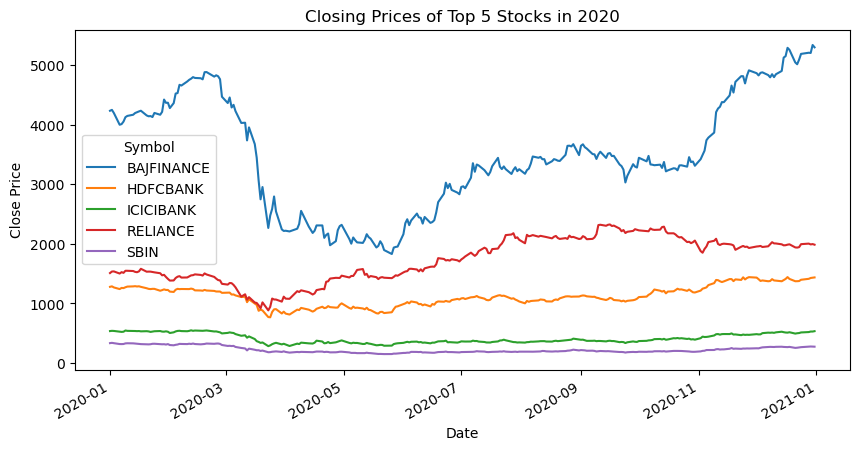

In [8]:
# code here

df = pd.read_csv("https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/export?format=csv")

df["Date"] = pd.to_datetime(df["Date"])
df_2020 = df[df["Date"].dt.year == 2020]

top5 = df_2020.groupby("Symbol")["Turnover"].sum().nlargest(5).index

pivot_df = df_2020[df_2020["Symbol"].isin(top5)].pivot_table(
    index="Date",
    columns="Symbol",
    values="Close",
    aggfunc="mean"
)

pivot_df.plot(figsize=(10,5), title="Closing Prices of Top 5 Stocks in 2020")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

### `Problem-7` Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
* Color on Symbol Column

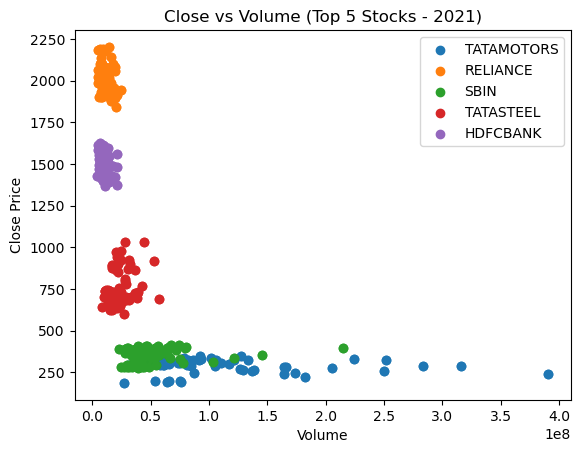

In [9]:
# code here

df["Date"] = pd.to_datetime(df["Date"])
df_2021 = df[df["Date"].dt.year == 2021]

top5 = df_2021.groupby("Symbol")["Turnover"].sum().nlargest(5).index
d = df_2021[df_2021["Symbol"].isin(top5)]

for s in top5:
    x = d[d["Symbol"] == s]
    plt.scatter(x["Volume"], x["Close"], label=s)

plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.title("Close vs Volume (Top 5 Stocks - 2021)")
plt.legend()
plt.show()

### `Problem-8` Create a 3-D Scatter Plot using `time,x,y` on below synthetic data. and give color gradiant on `z`
```
# Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
```

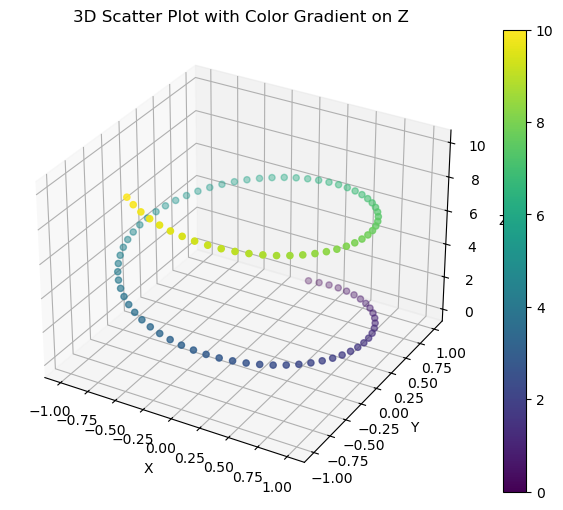

In [10]:
# code here


time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(data["x"], data["y"], data["z"], c=data["z"], cmap="viridis")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Scatter Plot with Color Gradient on Z")

fig.colorbar(sc, ax=ax)

plt.show()

### `Problem 9:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = sin(\sqrt{x^2 + y^2})$$


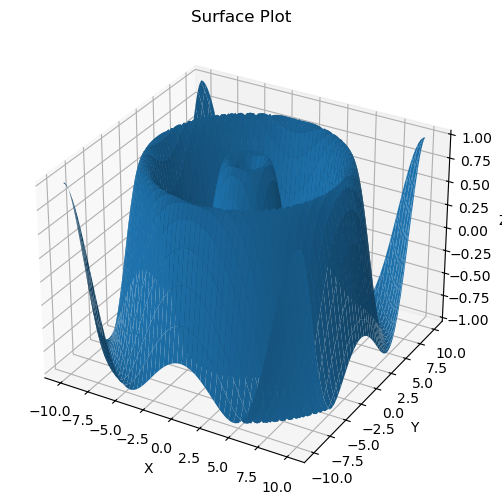

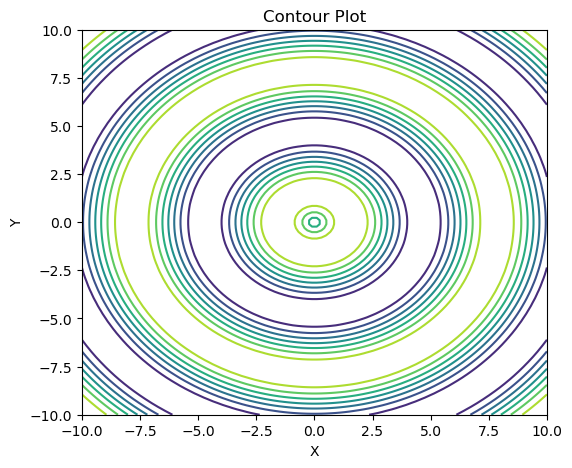

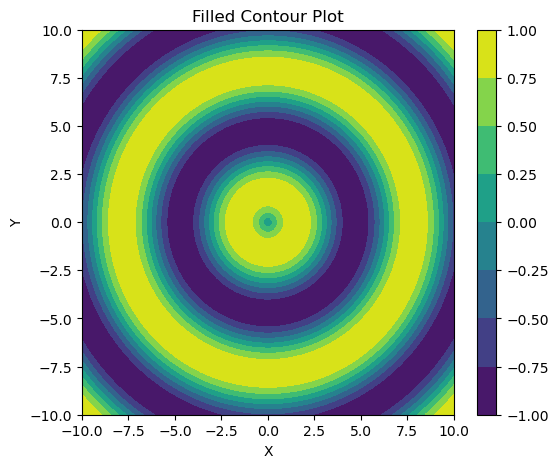

In [11]:
# code here

x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
x, y = np.meshgrid(x, y)

z = np.sin(np.sqrt(x**2 + y**2))

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z)
ax.set(title="Surface Plot", xlabel="X", ylabel="Y", zlabel="Z")
plt.show()

plt.figure(figsize=(6,5))
plt.contour(x, y, z)
plt.title("Contour Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

plt.figure(figsize=(6,5))
plt.contourf(x, y, z)
plt.title("Filled Contour Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()
plt.show()

### `Problem 10:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = tan(\log_2({x^2 + y^2})$$

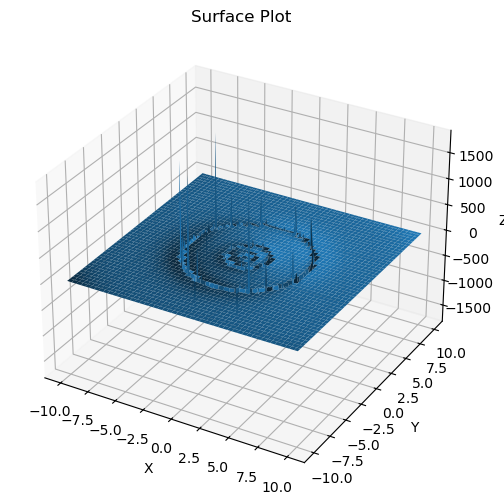

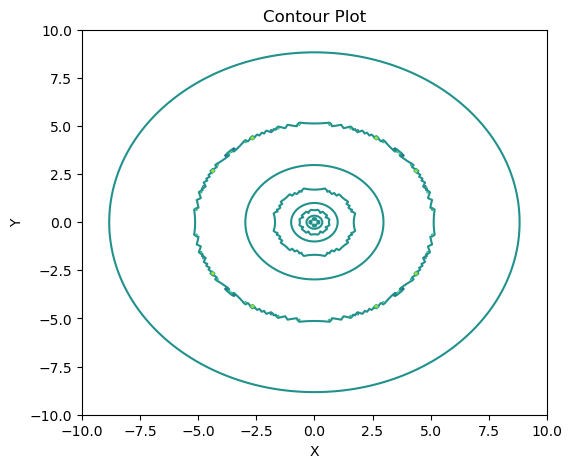

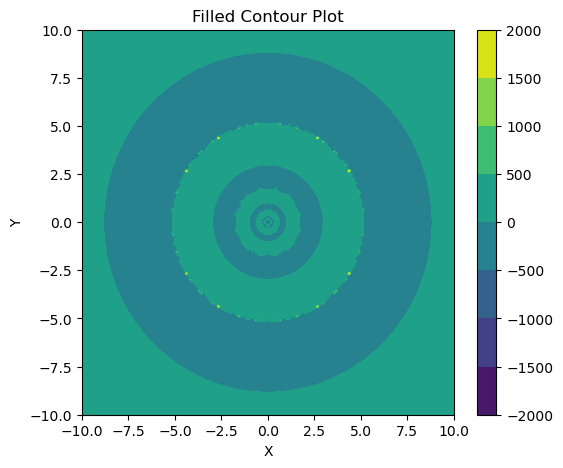

In [12]:
# code here

x = np.linspace(-10, 10, 200)
y = np.linspace(-10, 10, 200)
x, y = np.meshgrid(x, y)

r = x**2 + y**2
r[r == 0] = 1e-6
z = np.tan(np.log2(r))

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z)
ax.set(title="Surface Plot", xlabel="X", ylabel="Y", zlabel="Z")
plt.show()

plt.figure(figsize=(6,5))
plt.contour(x, y, z)
plt.title("Contour Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

plt.figure(figsize=(6,5))
plt.contourf(x, y, z)
plt.title("Filled Contour Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar()
plt.show()